# Demofile Calculate Isochrones
Demofile to calculate isochrones for a region and day interactively. Not meant for to reproduce the results of this project but to show how some functions work.  
For easier calculation for multiple days and regions, please use the main.py or calculate_isochrones.py file.

In [46]:
import geopandas as gpd
import networkx as nx
import osmnx as ox
from shapely.geometry import Point, LineString
import numpy as np

import calculate_isochrones as ci
from config import *

In [38]:
# Config:

# Prerequisites:
# Needs a valid stop category file in data/out/stops/ folder. If not, run calculate_categories.py or demo_calculate_categories.ipynb first.

region_graphs = {"city": "Vienna", "country": "Austria"} #select one from GRAPH_REGIONS in config.py
region_stops = "vor" #name of file in data/in/stops/ folder, must contain stops graph region
selected_day = 20240131 #selected day for isochrone calculation in format YYYYMMDD

# parameters for isochrone calculation
edge_snapping = "partial" #if "all", use edge snapping for all stops. "partial" for edge snapping for node further away than nearest_node_threshold. "none" for no edge snapping.
network_type = "walk" #network type for osmnx
crs = "epsg:31287" #crs of input data e.g. GTFS
nearest_node_threshold = 50 #maximum distance in meters to consider a node as a stop. Otherwise use edge snapping.
buffer = 25 #buffer size in meters. Smooths the isochrones.

In [39]:
# loads graph for region and 
graph = ci.load_graph(region_graphs, network_type=network_type, crs=crs)
stops = ci.load_stops(region_stops, selected_day, crs=crs)

display(stops.head())

Loading existing graph for Vienna
Combining and projecting graphs


,stop_id,stop_name,stop_lat,stop_lon,rank,count,interval,category,x,y
0,at:41:10005,Sieggraben Gemeindeamt,47.649966,16.379351,3,111,15.135135,3,628764.998391,421200.487965
1,at:41:10018,Antau Kleine Zeile,47.774498,16.475309,3,36,46.666667,5,635407.069652,435317.271767
2,at:41:10019,Stöttera Ost,47.769928,16.464412,3,37,45.405405,5,634611.747521,434776.778490
3,at:41:10020,Zemendorf Volksschule,47.765448,16.454648,3,37,45.405405,5,633900.629523,434249.811357
4,at:41:10021,Zemendorf Wr. Neustädter Str.,47.762356,16.451638,3,37,45.405405,5,633689.068862,433897.409845


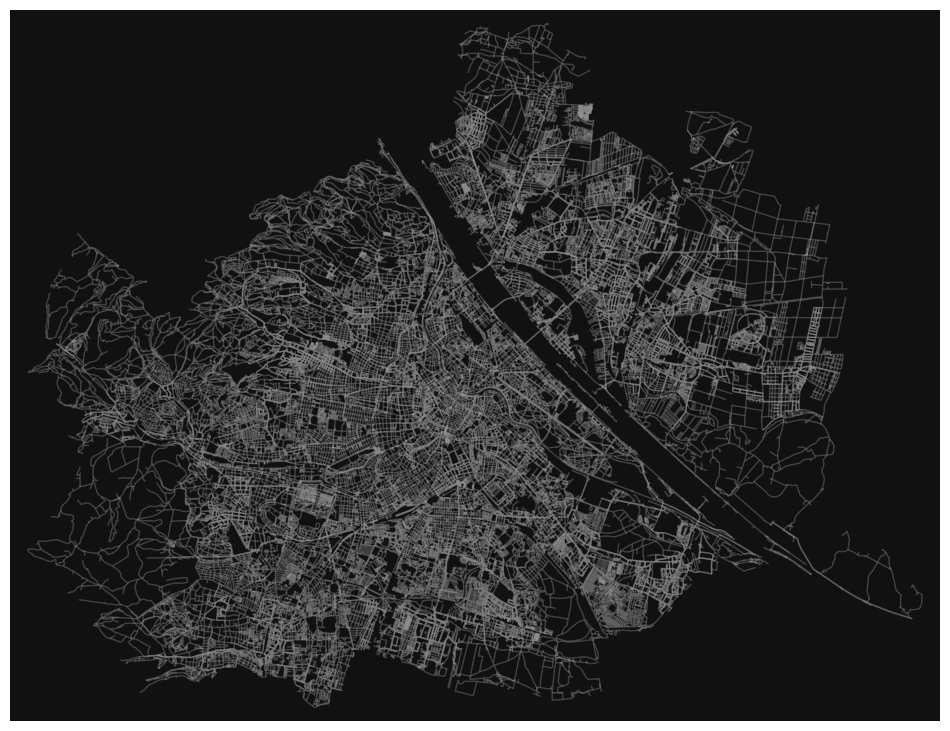

In [40]:
ci.draw_graph(graph, ns=0, nc="none")

In [41]:
nodes = []
dists = []
ids_far_away = []
nodes_far_away_lengths = []

if edge_snapping != "none":
    # fill in missing edge geometry if some kind of snapping is used since some edges have no geometry attribute
    for u, v, k, data in graph.edges(keys=True, data=True):
        if "geometry" not in data:
            data["geometry"] = LineString([
                (graph.nodes[u]["x"], graph.nodes[u]["y"]),
                (graph.nodes[v]["x"], graph.nodes[v]["y"])
            ])

if edge_snapping == "all":
    # if snapping is all, use edge snapping for all stops
    nodes_far_away_lengths = ci.reachable_nodes_from_snapped_point(graph, stops["x"], stops["y"], DISTANCES[-1])
else:
    # for each stop select the closest node in the graph to represent it
    nodes, dists = ox.nearest_nodes(graph, stops['x'], stops['y'], return_dist=True)

    if edge_snapping == "partial":
        # if snapping is partial, use edge snapping for nodes further away than nearest_node_threshold
        ids_far_away = np.where(dists > nearest_node_threshold)[0]
        nodes_far_away_df = stops.iloc[ids_far_away]
        nodes_far_away_lengths = ci.reachable_nodes_from_snapped_point(graph, nodes_far_away_df["x"], nodes_far_away_df["y"], DISTANCES[-1])


DISTANCES.sort() #smallest to largest

In [42]:
records = []
node_far_away_counter = 0
for index, row in stops.iterrows():
    cat = row["category"]

    if edge_snapping == "all":
        # if snapping is all, simply use precalculated node lengths for all stops at position of index
        lengths = nodes_far_away_lengths[index]
    elif edge_snapping == "partial" and dists[index] > nearest_node_threshold:
        # if snapping is partial, use precalculated node lengths for stops further away than nearest_node_threshold with counter variable
        lengths = nodes_far_away_lengths[node_far_away_counter]
        node_far_away_counter += 1
    else:
        # in any other case i.e. node is close enough to stop or snapping is none, run dijkstra for closest node
        lengths = nx.single_source_dijkstra_path_length(
            graph,
            nodes[index],
            cutoff=DISTANCES[-1],
            weight="length"
        )

    nodes_sorted = sorted(lengths.items(), key=lambda x: x[1])
    selected_nodes = []
    i = 0
    # for each distance, select all nodes in the distance band
    for d in DISTANCES:
        color = PTSQL_COLORS[ci.assign_color(cat, d)]
        if color == "none": #skip black areas
            break #skip entire loop for this node/stop since there are no colored isos left

        while i < len(nodes_sorted) and nodes_sorted[i][1] <= d:
            selected_nodes.append(Point((graph.nodes[nodes_sorted[i][0]]["x"], graph.nodes[nodes_sorted[i][0]]["y"])))
            i += 1

        if selected_nodes:
            poly = gpd.GeoSeries(selected_nodes).union_all().convex_hull.buffer(buffer)

            records.append({
                "center": index,
                "distance": d,
                "color": color,
                "geometry": poly
            })

gdf = gpd.GeoDataFrame(records, crs=crs)

In [43]:
# dissolve polygons of same color into one shape (Multipolygon) and reorder by reversed PTSQL_COLORS (largest shape first)
# this allows plotting the polygons in the correct order to make smaller polygons on top of larger ones
gdf = gdf.dissolve(by="color").reindex(PTSQL_COLORS[::-1])

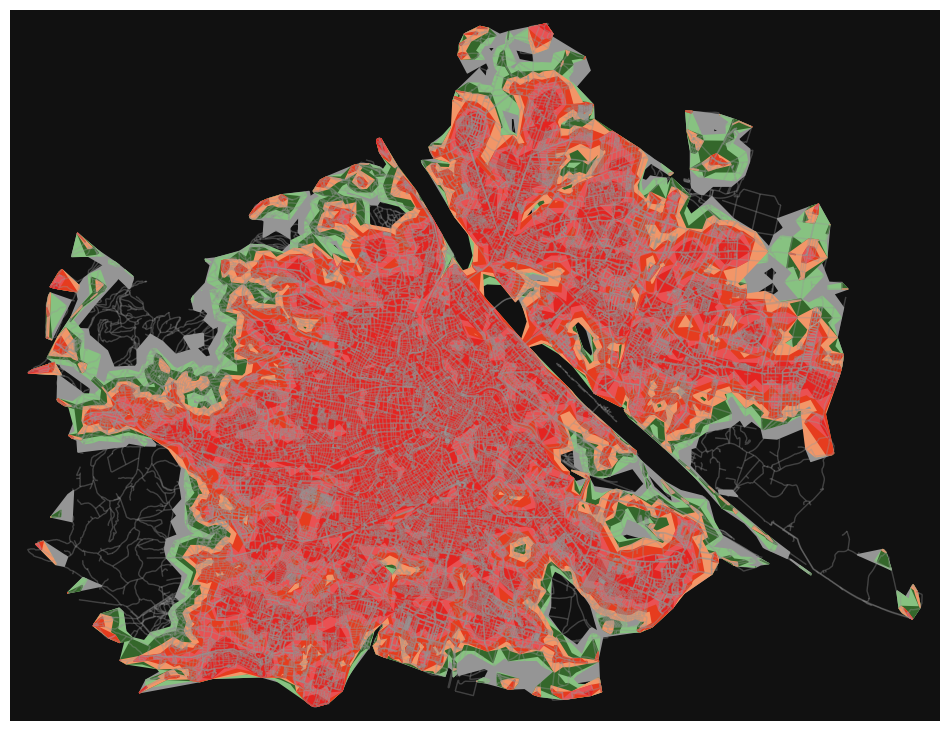

In [44]:
ci.draw_graph(graph, ns=0, nc="none", gdf=gdf, return_fig=False)

In [45]:
# save gdf to file
name = ci.create_name(region_graphs, edge_snapping) + f"_{selected_day}"
gdf.to_file(f"{PATH_OUT_ISOCHRONES}{name}.gpkg", layer="isochrones", driver="GPKG")